# PyBullet 2-link arm RL 비교

하나의 동일한 2-link arm 환경에서 **CEM / PPO / SAC를 각각 독립적으로 학습**한 뒤 결과를 같은 형식으로 비교합니다.

상태는

$$
x=(q_1,q_2,\dot q_1,\dot q_2)\in\mathbb{R}^4
$$

이고 제어입력은

$$
u=(\tau_1,\tau_2)\in\mathbb{R}^2
$$

입니다.

동역학은

$$
M(q)\ddot q+C(q,\dot q)\dot q+g(q)+B\dot q=\tau
$$

를 사용합니다.

각 알고리즘의 early / middle / final policy rollout을 PyBullet 로봇팔 애니메이션과 $(q_1,q_2)$, $(q_1,\dot q_1)$, $(q_2,\dot q_2)$ 상태공간에 동기화해 봅니다.

In [1]:
!pip -q install pybullet gymnasium stable-baselines3 imageio imageio-ffmpeg
!git clone -q https://github.com/HisameOgasahara/RL_tmp.git
%cd RL_tmp

import sys
sys.path.insert(0, ".")

from IPython.display import Video, display
import matplotlib.pyplot as plt

from src.rl_tmp.two_link_arm.env import TwoLinkArmEnv
from src.rl_tmp.two_link_arm.render import (
    rollout_policy,
    render_rollout_video,
    stable_baselines_policy,
)

env_kwargs = {
    "dt": 0.04,
    "horizon": 150,
    "target": (1.25, 1.0),
    "initial_state": (0.0, 0.0, 0.0, 0.0),
    "random_reset": True,
}


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.5/80.5 MB 7.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 187.6/187.6 kB 11.8 MB/s eta 0:00:00
/content/RL_tmp


## 1. CEM

정책 parameter vector를 직접 샘플링하고, episode return이 높은 elite 집합으로 sampling distribution을 갱신합니다.

/content/RL_tmp/src/rl_tmp/two_link_arm/env.py:77: RuntimeWarning: overflow encountered in cast
  return np.array(
/content/RL_tmp/src/rl_tmp/two_link_arm/cem.py:82: RuntimeWarning: invalid value encountered in matmul
  observation @ w1 + b1
/content/RL_tmp/src/rl_tmp/two_link_arm/dynamics.py:90: RuntimeWarning: overflow encountered in scalar multiply
  -h * (2.0 * dq1 * dq2 + dq2 * dq2),
/content/RL_tmp/src/rl_tmp/two_link_arm/dynamics.py:90: RuntimeWarning: invalid value encountered in scalar add
  -h * (2.0 * dq1 * dq2 + dq2 * dq2),
/content/RL_tmp/src/rl_tmp/two_link_arm/dynamics.py:91: RuntimeWarning: overflow encountered in scalar multiply
  h * dq1 * dq1,
/content/RL_tmp/src/rl_tmp/two_link_arm/dynamics.py:85: RuntimeWarning: invalid value encountered in sin
  * np.sin(q2)
/content/RL_tmp/src/rl_tmp/two_link_arm/dynamics.py:110: RuntimeWarning: invalid value encountered in cos
  * np.cos(q1)
/content/RL_tmp/src/rl_tmp/two_link_arm/dynamics.py:114: RuntimeWarning: invalid value e

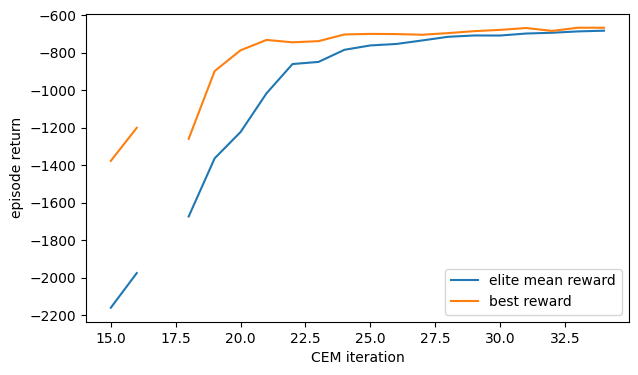

In [2]:
from src.rl_tmp.two_link_arm.cem import (
    CEMPolicy,
    train_cem,
)

cem_result = train_cem(
    env_kwargs=env_kwargs,
    iterations=35,
    population_size=192,
    elite_fraction=0.12,
    seed=0,
)

plt.figure(figsize=(7, 4))
plt.plot(
    cem_result.history["elite_mean_reward"],
    label="elite mean reward",
)
plt.plot(
    cem_result.history["best_reward"],
    label="best reward",
)
plt.xlabel("CEM iteration")
plt.ylabel("episode return")
plt.legend()
plt.show()


In [3]:
for name in ["early", "middle", "final"]:
    env = TwoLinkArmEnv(**env_kwargs)

    policy = CEMPolicy(
        cem_result.checkpoints[name]
    )

    rollout = rollout_policy(
        policy,
        env,
        seed=123,
    )

    path = render_rollout_video(
        rollout,
        f"/content/two_link_cem_{name}.mp4",
        config=env.config,
        fps=25,
        frame_stride=2,
    )

    print("CEM:", name)
    display(Video(str(path), embed=True))


CEM: early


CEM: middle


CEM: final


## 2. PPO

현재 policy가 직접 데이터를 만드는 **on-policy actor-critic**입니다.

In [4]:
from src.rl_tmp.two_link_arm.ppo import train_ppo

ppo_model, ppo_snapshots = train_ppo(
    env_kwargs=env_kwargs,
    total_timesteps=80_000,
    seed=0,
    device="auto",
)


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


----------------------------------
| rollout/           |           |
|    ep_len_mean     | 150       |
|    ep_rew_mean     | -3.75e+03 |
| time/              |           |
|    fps             | 800       |
|    iterations      | 1         |
|    time_elapsed    | 1         |
|    total_timesteps | 1024      |
----------------------------------


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 150          |
|    ep_rew_mean          | -3.79e+03    |
| time/                   |              |
|    fps                  | 714          |
|    iterations           | 2            |
|    time_elapsed         | 2            |
|    total_timesteps      | 2048         |
| train/                  |              |
|    approx_kl            | 0.0070059607 |
|    clip_fraction        | 0.0586       |
|    clip_range           | 0.2          |
|    entropy_loss         | -2.84        |
|    explained_variance   | 0.000478     |
|    learning_rate        | 0.0003       |
|    loss                 | 8.27e+04     |
|    n_updates            | 10           |
|    policy_gradient_loss | -0.0112      |
|    std                  | 1            |
|    value_loss           | 1.82e+05     |
------------------------------------------
-----------------------------------------
| rollout/  

In [5]:
for name in ["early", "middle", "final"]:
    ppo_model.policy.load_state_dict(
        ppo_snapshots[name]
    )

    env = TwoLinkArmEnv(**env_kwargs)

    policy = stable_baselines_policy(
        ppo_model,
        deterministic=False,
    )

    rollout = rollout_policy(
        policy,
        env,
        seed=123,
    )

    path = render_rollout_video(
        rollout,
        f"/content/two_link_ppo_{name}.mp4",
        config=env.config,
        fps=25,
        frame_stride=2,
    )

    print("PPO:", name)
    display(Video(str(path), embed=True))


/usr/local/lib/python3.13/dist-packages/matplotlib/_mathtext.py:2170: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  result = self._expression.parseString(s)
/usr/local/lib/python3.13/dist-packages/pyparsing/util.py:466: PyparsingDeprecationWarning: 'parseAll' argument is deprecated, use 'parse_all'
  return fn(self, *args, **kwargs)
/usr/local/lib/python3.13/dist-packages/matplotlib/_mathtext.py:2178: PyparsingDeprecationWarning: 'resetCache' deprecated - use 'reset_cache'
  ParserElement.resetCache()


PPO: early


PPO: middle


PPO: final


## 3. SAC

Replay buffer를 쓰는 **off-policy actor-critic**이며 entropy objective를 포함합니다.

In [ ]:
from src.rl_tmp.two_link_arm.sac import train_sac

sac_model, sac_snapshots = train_sac(
    env_kwargs=env_kwargs,
    total_timesteps=80_000,
    seed=0,
    device="auto",
)


Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
----------------------------------
| rollout/           |           |
|    ep_len_mean     | 150       |
|    ep_rew_mean     | -3.99e+03 |
| time/              |           |
|    episodes        | 4         |
|    fps             | 1289      |
|    time_elapsed    | 0         |
|    total_timesteps | 600       |
----------------------------------
----------------------------------
| rollout/           |           |
|    ep_len_mean     | 150       |
|    ep_rew_mean     | -3.98e+03 |
| time/              |           |
|    episodes        | 8         |
|    fps             | 190       |
|    time_elapsed    | 6         |
|    total_timesteps | 1200      |
| train/             |           |
|    actor_loss      | 32.7      |
|    critic_loss     | 147       |
|    ent_coef        | 0.943     |
|    ent_coef_loss   | -0.193    |
|    learning_rate   | 0.0003    |
|    n_updates       | 199     

In [ ]:
for name in ["early", "middle", "final"]:
    sac_model.policy.load_state_dict(
        sac_snapshots[name]
    )

    env = TwoLinkArmEnv(**env_kwargs)

    policy = stable_baselines_policy(
        sac_model,
        deterministic=False,
    )

    rollout = rollout_policy(
        policy,
        env,
        seed=123,
    )

    path = render_rollout_video(
        rollout,
        f"/content/two_link_sac_{name}.mp4",
        config=env.config,
        fps=25,
        frame_stride=2,
    )

    print("SAC:", name)
    display(Video(str(path), embed=True))


## 비교 포인트

세 방법 모두 동일한 Euler-Lagrange 물리계와 동일한 상태/행동 공간을 사용합니다.

따라서 비교할 것은 **어떤 방식으로 정책을 탐색하고 갱신했는가**와 그 결과로 **어떤 실제 팔 움직임과 상태공간 궤적이 나왔는가**입니다.

세부 설명은 `docs/two_link_arm.md`에 정리되어 있습니다.